In [127]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import (
    StandardScaler, 
    LabelEncoder
)
from sklearn.svm import SVC, SVR
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from typing import List, Optional, Tuple, Union


## CARGA DE DATOS CSV

In [128]:
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"
df_hotel = pd.read_csv(CSV_HOTEL_PATH)

## PREPROCESAMIENTO DE DATOS

In [129]:
# Generamos una copia de los datos en crudo para tener siempre un punto de referencia de partida.
df_hotel_prep = df_hotel.copy()

In [130]:
# Eliminamos celdas duplicadas
print(f"Shape before removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number before: {df_hotel_prep.duplicated(keep=False).sum()}")
df_hotel_prep = df_hotel_prep.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number after: {df_hotel_prep.duplicated(keep=False).sum()}")

Shape before removing duplicates: (119390, 32)
Duplicated number before: 40165
Shape after removing duplicates: (87396, 32)
Duplicated number after: 0


In [131]:
# Sustituimos valores de niños null con 0 (asumimos null como 0)
print(f"Null values of children before: {df_hotel_prep['children'].isna().sum()}")
df_hotel_prep['children'] = df_hotel_prep['children'].fillna(0)
print(f"Null values of children after: {df_hotel_prep['children'].isna().sum()}")

Null values of children before: 4
Null values of children after: 0


In [132]:
# Eliminamos aquellos datos con precio medio de estancia negativo, pues son valores sin sentido (no se paga a los clientes por hacer uso de las instalaciones).
df_hotel_prep = df_hotel_prep[df_hotel_prep['adr'] >= 0].reset_index(drop=True)

# Descartamos aquellas reservas donde no exista al menos 1 cliente, pues representa una situación sin sentido.
df_hotel_prep = df_hotel_prep[
    df_hotel_prep['adults'].fillna(0) + df_hotel_prep['children'].fillna(0) + df_hotel_prep['babies'].fillna(0) > 0
].reset_index(drop=True)

print(f"Shape tras limpieza de filas inválidas: {df_hotel_prep.shape}")

Shape tras limpieza de filas inválidas: (87229, 32)


In [133]:
# Agrupar los paises con frecuencia < 0.1%
frequencies = df_hotel_prep['country'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.001].index
df_hotel_prep['country'] = np.where(
    df_hotel_prep['country'].isna() | df_hotel_prep['country'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['country']
)
print(f"{df_hotel_prep['country'].value_counts(normalize=True)}")

country
PRT       0.313600
GBR       0.119490
FRA       0.101148
ESP       0.083046
DEU       0.061734
ITA       0.035092
IRL       0.034564
Others    0.030838
BEL       0.023857
BRA       0.022848
NLD       0.021896
USA       0.021449
CHE       0.017953
CN        0.012530
AUT       0.010856
SWE       0.009550
CHN       0.009355
POL       0.008759
RUS       0.006408
NOR       0.005904
ROU       0.005251
FIN       0.004826
ISR       0.004620
DNK       0.004402
AUS       0.004333
AGO       0.003921
LUX       0.002992
MAR       0.002660
TUR       0.002442
ARG       0.002327
HUN       0.002316
JPN       0.002098
IND       0.001628
CZE       0.001559
KOR       0.001364
GRC       0.001341
HRV       0.001043
Name: proportion, dtype: float64


In [134]:
# Agrupar los canales de distribución con frecuencia < 1% — 'Undefined' se conserva como categoría propia
frequencies = df_hotel_prep['distribution_channel'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['distribution_channel'] = np.where(
    df_hotel_prep['distribution_channel'].isin(index_low_frequency),
    'others',
    df_hotel_prep['distribution_channel']
)
print(f"{df_hotel_prep['distribution_channel'].value_counts(normalize=True)}")

distribution_channel
TA/TO        0.791342
Direct       0.148494
Corporate    0.058031
others       0.002132
Name: proportion, dtype: float64


In [135]:
# Agrupar el segmento de mercado con frecuencia <= 1%
frequencies = df_hotel_prep['market_segment'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['market_segment'] = np.where(
    df_hotel_prep['market_segment'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['market_segment']
)
print(f"{df_hotel_prep['market_segment'].value_counts(normalize=True)}")

market_segment
Online TA        0.591008
Offline TA/TO    0.158835
Direct           0.135047
Groups           0.056415
Corporate        0.048149
Others           0.010547
Name: proportion, dtype: float64


In [136]:
df_hotel.tail(20).T

,119370,119371,119372,119373,119374,119375,119376,119377,119378,119379,119380,119381,119382,119383,119384,119385,119386,119387,119388,119389
hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
lead_time,201,175,175,175,201,200,165,185,247,109,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,August,August,August,August,August,August,August,August,August,August,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,30,31,31,31,29,30,29,30,31,31,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,4,3,3,3,5,4,5,4,3,3,3,3,4,4,5,5,5,5,5,7
adults,1,2,1,1,2,2,3,2,2,2,2,2,3,2,2,2,3,2,2,2


In [137]:
# Sustituimos la columna agente por agente conocido (1) o no (0)
df_hotel_prep['agent_known'] = df_hotel_prep['agent'].notna().astype(int)
df_hotel_prep.drop(columns=['agent'], inplace=True)
df_hotel_prep.tail(10).T


,87219,87220,87221,87222,87223,87224,87225,87226,87227,87228
hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,0,0,0,0,0
lead_time,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,3,3,4,4,5,5,5,5,5,7
adults,2,2,3,2,2,2,3,2,2,2


In [138]:
# Nueva columna indicando si ambas coinciden
df_hotel_prep['reserved_assigned_room'] = (df_hotel_prep['reserved_room_type'] == df_hotel_prep['assigned_room_type']).astype(int)
df_hotel_prep['reserved_assigned_room']

# SOLO PARA REGRESION LOGISTICA O REDES NEURONALES
# df_hotel_prep.drop(columns=['reserved_room_type', 'assigned_room_type'], inplace=True)

0        1
1        1
2        0
3        1
4        1
        ..
87224    1
87225    1
87226    1
87227    1
87228    1
Name: reserved_assigned_room, Length: 87229, dtype: int32

In [139]:
# Sustituir undefined por NA (No Aplica)
df_hotel_prep['meal'] = df_hotel_prep['meal'].replace('Undefined', 'NA')
df_hotel_prep['meal'].value_counts(normalize=True)

meal
BB    0.778480
SC    0.107659
HB    0.104094
NA    0.005640
FB    0.004127
Name: proportion, dtype: float64

In [140]:
drop_columns = [
    'company',
    'arrival_date_year',          # Sobreajusta a años concretos
    'arrival_date_week_number',   # Redundante con mes
    'reservation_status_date',    # Es post-evento, data leakage
    'reservation_status',         # Puede provocar overfitting
]
df_hotel_prep.drop(columns=drop_columns, inplace=True)


In [141]:
frecuencias = df_hotel_prep['children'].value_counts(normalize=True) # Agrupar
valores_raros = frecuencias[frecuencias < 0.01].index.tolist()
#df_hotel_prep['children'] = df_hotel_prep['children'].replace(valores_raros, 3)
df_hotel_prep['children'].value_counts(normalize=True)

children
0.0     0.904114
1.0     0.053824
2.0     0.041190
3.0     0.000860
10.0    0.000011
Name: proportion, dtype: float64

In [142]:
frecuencias = df_hotel_prep['adults'].value_counts(normalize=True) # Agrupar 
valores_raros = frecuencias[frecuencias < 0.01].index.tolist()
#df_hotel_prep['adults'] = df_hotel_prep['adults'].replace(valores_raros, 0)
df_hotel_prep['adults'].value_counts(normalize=True)

adults
2     0.739387
1     0.189192
3     0.068039
0     0.002511
4     0.000688
26    0.000057
27    0.000023
20    0.000023
5     0.000023
40    0.000011
50    0.000011
55    0.000011
6     0.000011
10    0.000011
Name: proportion, dtype: float64

In [143]:
frecuencias = df_hotel_prep['babies'].value_counts(normalize=True) # Agrupar 
valores_raros = frecuencias[frecuencias < 0.01].index.tolist()
#df_hotel_prep['babies'] = df_hotel_prep['babies'].replace(valores_raros, 2)
df_hotel_prep['babies'].value_counts(normalize=True)

babies
0     0.989522
1     0.010283
2     0.000172
10    0.000011
9     0.000011
Name: proportion, dtype: float64

In [144]:
hotel_values = {
    'City Hotel': 0,
    'Resort Hotel': 1
}

df_hotel_prep['hotel'] = df_hotel_prep['hotel'].replace(hotel_values)

C:\Users\anpei\AppData\Local\Temp\ipykernel_21188\2093930135.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [145]:
MONTHS = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
          'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df_hotel_prep['arrival_date_month'] = df_hotel_prep['arrival_date_month'].map(MONTHS)

In [146]:
df_hotel_prep['meal'] = df_hotel_prep['meal'].map(
   {m: i for i, m in enumerate(df_hotel_prep['meal'].unique().tolist())})
df_hotel_prep['meal'].value_counts()

meal
0    67906
3     9391
2     9080
4      492
1      360
Name: count, dtype: int64

In [147]:
columnas_object = df_hotel_prep.select_dtypes(include=['object']).columns.tolist()
for col in columnas_object:
    df_hotel_prep[col] = LabelEncoder().fit_transform(df_hotel_prep[col].astype(str))

In [148]:
df_hotel_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87229 entries, 0 to 87228
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87229 non-null  int64  
 1   is_canceled                     87229 non-null  int64  
 2   lead_time                       87229 non-null  int64  
 3   arrival_date_month              87229 non-null  int64  
 4   arrival_date_day_of_month       87229 non-null  int64  
 5   stays_in_weekend_nights         87229 non-null  int64  
 6   stays_in_week_nights            87229 non-null  int64  
 7   adults                          87229 non-null  int64  
 8   children                        87229 non-null  float64
 9   babies                          87229 non-null  int64  
 10  meal                            87229 non-null  int64  
 11  country                         87229 non-null  int32  
 12  market_segment                  

#### Obtener variables X e y

In [149]:
# Hiperparámetros
random_state=42
max_depth_rf=10
n_estimators_rf=700
min_samples_split=5
min_samples_leaf=2

target_column = 'is_canceled'
X = df_hotel_prep.drop(columns=[target_column])
y = df_hotel_prep[target_column]

print(f"Percentage y: {y.value_counts(normalize=True)}")

Percentage y: is_canceled
0    0.724759
1    0.275241
Name: proportion, dtype: float64


In [150]:
# Preparación de los datos para el entrenamiento del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Define model
modelo_rfc = RandomForestClassifier(n_estimators=n_estimators_rf, max_depth=max_depth_rf, random_state=random_state, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)
print(f"Train data percentage: {y_train.value_counts(normalize=True)}")
print(f"Test data percentage: {y_test.value_counts(normalize=True)}")
model_rfc = modelo_rfc.fit(X_train, y_train)

Train data percentage: is_canceled
0    0.724331
1    0.275669
Name: proportion, dtype: float64
Test data percentage: is_canceled
0    0.72647
1    0.27353
Name: proportion, dtype: float64


In [151]:
y_predict = model_rfc.predict(X_test)
y_predict_proba = model_rfc.predict_proba(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_predict_proba[:, 1])

print(f"Accuracy (Cancelaciones sobre el total):        {acc:.2%}")
print(f"Precisión (Cancelaciones predichas acertadas):  {prec:.2%}")
print(f"Recall (Cancelaciones predichas vs reales):     {rec:.2%}")
print(f"F1-Score (media entre precision y recall):      {f1:.2%}")
print(f"AUC:                                            {auc:.2%}\n")

Accuracy (Cancelaciones sobre el total):        81.97%
Precisión (Cancelaciones predichas acertadas):  75.54%
Recall (Cancelaciones predichas vs reales):     50.42%
F1-Score (media entre precision y recall):      60.48%
AUC:                                            87.43%



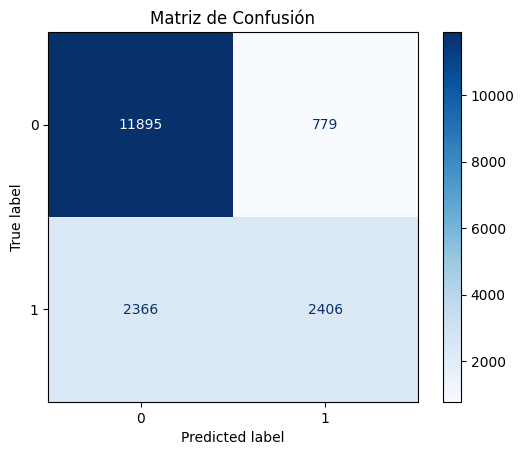

In [152]:
cm = confusion_matrix(y_test, y_predict)

# 3. Mostrarla de forma visual y bonita
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_rfc.classes_)
disp.plot(cmap='Blues')

plt.title('Matriz de Confusión')
plt.show()

In [153]:
X_test.columns

Index(['hotel', 'lead_time', 'arrival_date_month', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'agent_known', 'reserved_assigned_room'],
      dtype='object')

In [154]:
# Mostramos la importancia de las variables
modelo_rfc.feature_importances_

array([8.02857594e-03, 1.52703250e-01, 7.13745667e-03, 4.83034793e-03,
       7.13942344e-03, 1.54924587e-02, 4.73077360e-03, 3.84690217e-03,
       1.37486212e-04, 4.57651078e-03, 1.20549168e-01, 1.31398656e-01,
       2.30764816e-02, 3.59428092e-03, 3.94542572e-02, 9.54282208e-03,
       4.33535204e-03, 7.09707442e-03, 2.69549881e-02, 4.93381895e-02,
       8.52423135e-04, 3.28679778e-02, 3.79322494e-02, 8.41826061e-02,
       1.07352486e-01, 1.04461379e-02, 1.02401664e-01])

In [155]:
# Importancia de variables
col_importancia_rf = modelo_rfc.feature_importances_

df_importances_rf = pd.DataFrame({
    'variable' : X.columns,
    'importancia' : col_importancia_rf
})

df_importances_rf.sort_values(by=['importancia'], ascending=False)

# Ordenamos el dataframe por la importancia de manera ascendente
df_importances_rf = df_importances_rf.sort_values(by='importancia', ascending=True)

In [156]:
# Visualización de la importancia de las variables
fig = px.bar(
    df_importances_rf,
    x='importancia',
    y='variable',
    text='importancia',
    text_auto=".3%",
    title='Importancia de las variables en el modelo Random Forest',
    labels={'x': 'Importancia', 'y': 'Variable'},
    width=700, height=500
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

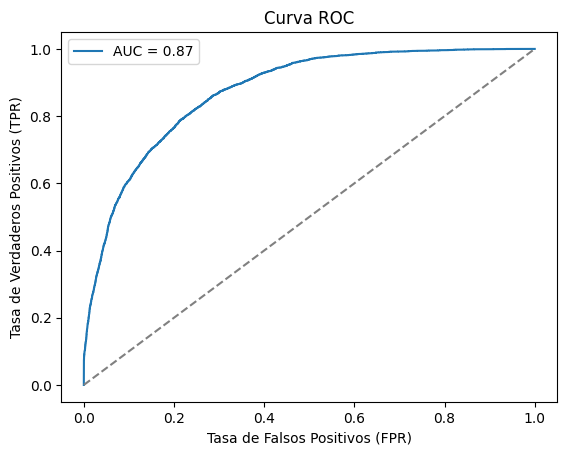

In [157]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_predict_proba[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()